# A* vs MCTS (Design-based)
This notebook compares A* and MCTS **on Design.py only**.
Data loading is reused from the original test; NewDesign / KMeansSampler pipelines are removed.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import time
import numpy as np
import matplotlib.pyplot as plt

import graphical_sampling as gs
from package_sampling.utils import inclusion_probabilities
from graphical_sampling.design import Design
from graphical_sampling.criteria.var_nht import VarNHT
from graphical_sampling.search.astar import AStar
from graphical_sampling.search.mcts import MCTS
from graphical_sampling.validation.design_validity import (
    check_probability_sum,
    check_fip_consistency,
)


## Load population CSVs (unchanged)

In [2]:
DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    coords = data[:, :2]
    probs  = data[:, -1]

    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name  = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict.setdefault(coord_name, {})[prob_name] = probs

print("Available populations:", coords_dict.keys())


Available populations: dict_keys(['AggregatedPop1027', 'cluster', 'grid', 'meuse', 'random', 'RegularPop1000', 'swiss'])


## Select dataset

In [3]:
rng = np.random.default_rng()
n = 4
coords = coords_dict['swiss']
base_probs = probs_dict['swiss']['unequal']          # همون چیزی که داشتی
aux = base_probs + rng.random(100)
pi = inclusion_probabilities(aux, n=n)        # این میشه inclusion probabilities معتبر

initial_design = Design(pi)

## Build initial Design (Design.py)

Initial VarNHT: 11.681651829116863


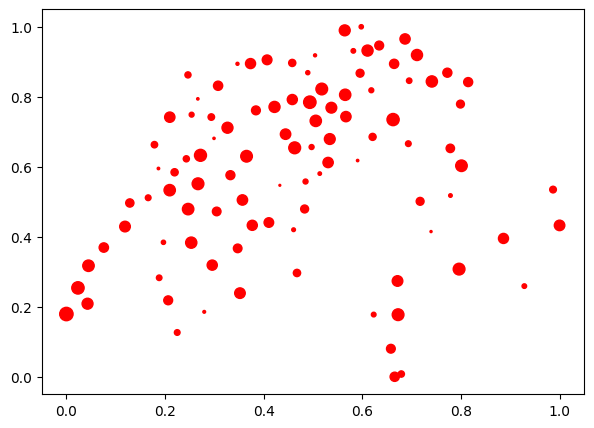

In [4]:
initial_design = Design(pi)

criteria = VarNHT(
    auxiliary_variable=base_probs,
    inclusion_probability=pi,
)

initial_value = criteria(initial_design)
print("Initial VarNHT:", initial_value)
print(initial_design)

import matplotlib.pyplot as plt
x = coords[:, 0]
y = coords[:, 1]

plt.figure(figsize=(7,5))
plt.scatter(x, y, s=1000*pi, color = 'red')
plt.show()

## Run A* (Design-based)

In [18]:
astar = AStar(
    initial_design=initial_design,
    criteria=criteria,
    switch_coefficient=0.5,
    random_pull= False,
    threshold=1e-6,
)
t0 = time.perf_counter()
astar_iters = astar.run(
    max_iterations=200,
    num_new_nodes=10,
    max_open_set_size=1000,
    num_changes=5,
)
elapsed_astar = time.perf_counter() - t0

print("A* iterations:", astar_iters)
print("A* best VarNHT:", astar.best_criteria_value)
print("A* time (s):", round(elapsed_astar, 3))


A* iterations: 200
A* best VarNHT: 10.644648580066296
A* time (s): 0.822


## Run MCTS (Design-based)

In [23]:
import time
# =====================================================
# 1) Run MCTS
# =====================================================
t0 = time.perf_counter()

mcts = MCTS(
        initial_design,
        criteria,
        base_changes=10
)

best_design, best_value = mcts.run(
        max_iterations=200,
        max_children_per_node=3,
        rollout_depth=50,
)


elapsed_mcts = time.perf_counter() - t0

print("MCTS best VarNHT:", best_value)
print("MCTS time (s):", round(elapsed_mcts, 3))

# =====================================================
# 2) Validation — exactly what the professor asked
# =====================================================
print("\n=== VALIDATION: Best MCTS Design ===")

# ---- (A) Sum of probabilities = 1
ok_prob, prob_sum = check_probability_sum(best_design)

print("Probability sum:", prob_sum)
print("Probability sum OK:", ok_prob)

# ---- (B) FIP reconstruction check
ok_fip, max_diff, _ = check_fip_consistency(
    best_design,
    probs,   # original inclusion probabilities
)

print("FIP consistency OK:", ok_fip)
print("Max |FIP - reconstructed|:", max_diff)

# ----------------------------
# 3) Safety assertions
# ----------------------------
assert ok_prob, "❌ Sample probabilities do not sum to 1"
assert ok_fip, "❌ Reconstructed FIP does not match original FIP"

print("✅ All MCTS sample validity checks passed.")


=== MCTS INITIALIZED ===
Initial Var: 11.681651829116863
------------------------
=== MCTS RUN STARTED ===
Max iterations: 200
------------------------

>>> ITERATION 0
  SELECTED NODE | depth = 0 | visits = 0 | children = 0
  EXPAND | depth = 0 | rollout_improved = False | mutations = 11
parent:  <graphical_sampling.search.mcts.MCTSNode object at 0x000001A767B15900>
new_design's parent:  <graphical_sampling.search.mcts.MCTSNode object at 0x000001A767B15900>
length of node.children:  1
  SIMULATE | start Var = 11.29890501476391
  ROLLOUT RESULT | best Var = 11.14092024729986 | reward = 0.023692841455663863
  >>> GLOBAL BEST UPDATE: 11.681651829116863 → 11.14092024729986
  BACKPROP | reward = 0.023692841455663863 | from depth = 1
  EXPAND | depth = 0 | rollout_improved = True | mutations = 9
parent:  <graphical_sampling.search.mcts.MCTSNode object at 0x000001A767B15900>
new_design's parent:  <graphical_sampling.search.mcts.MCTSNode object at 0x000001A767B15900>
length of node.children: 

AssertionError: ❌ Reconstructed FIP does not match original FIP

## Final comparison

In [20]:
print("========== FINAL COMPARISON ==========")
print("Initial VarNHT :", initial_value)
print("A* VarNHT      :", astar.best_criteria_value)
print("MCTS VarNHT    :", best_value)


========== FINAL COMPARISON ==========
Initial VarNHT : 11.681651829116863
A* VarNHT      : 10.644648580066296
MCTS VarNHT    : 10.361203283911557
